# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 558.7/558.7 kB 29.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.12.1 requires huggingface-hub<2.0,>=1.5.0, but you have huggingface-hub 0.34.0 which is incompatible.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.34.0 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [98]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

from sklearn.impute import SimpleImputer

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform


# **Loading the dataset**

In [70]:
data = pd.read_csv('/content/SuperKart.csv')

In [71]:
superkart = data.copy()

# **Data Overview**

In [72]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns")

There are 8763 rows and 12 columns


In [73]:
for i,col in enumerate(superkart.columns):
  print(f"{i} {col}")

0 Product_Id
1 Product_Weight
2 Product_Sugar_Content
3 Product_Allocated_Area
4 Product_Type
5 Product_MRP
6 Store_Id
7 Store_Establishment_Year
8 Store_Size
9 Store_Location_City_Type
10 Store_Type
11 Product_Store_Sales_Total


In [74]:
superkart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [75]:
superkart.head(5)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [76]:
superkart.duplicated().sum()
# No dupes!

np.int64(0)

In [77]:
superkart.isnull().sum()
# No missing values

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


In [78]:
superkart["Store_Type"].unique()

array(['Supermarket Type2', 'Departmental Store', 'Supermarket Type1',
       'Food Mart'], dtype=object)

In [79]:
superkart["Product_Sugar_Content"] = superkart["Product_Sugar_Content"].replace("reg", "Regular")
superkart["Store_Type"] = superkart["Store_Type"].replace("Supermarket Type1", "Super Market Type")
superkart["Store_Type"] = superkart["Store_Type"].replace("Supermarket Type2", "Super Market Type")

In [113]:
superkart.drop(columns=["Product_Id"])

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Super Market Type,2842.40
1,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Super Market Type,4130.16
3,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Super Market Type,4132.18
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36
...,...,...,...,...,...,...,...,...,...,...,...
8758,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Super Market Type,3806.53
8759,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Super Market Type,5020.74
8760,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Super Market Type,2443.42
8761,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Super Market Type,4171.82


In [114]:
superkart["Product_Sugar_Content"]

,Product_Sugar_Content
0,Low Sugar
1,Low Sugar
2,Regular
3,Low Sugar
4,No Sugar
...,...
8758,No Sugar
8759,No Sugar
8760,No Sugar
8761,No Sugar


# **Exploratory Data Analysis (EDA)**

In [115]:
num_cols = ["Product_Weight", "Product_Allocated_Area", "Product_MRP",
            "Store_Establishment_Year", "Product_Store_Sales_Total"]
cat_cols = ["Product_Sugar_Content", "Product_Type", "Store_Size",
            "Store_Location_City_Type", "Store_Type"]


## Univariate Analysis

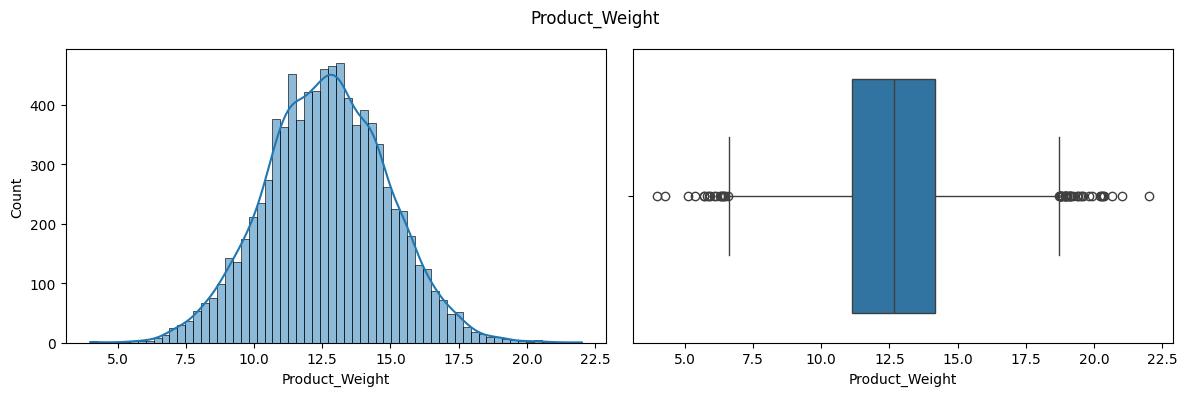

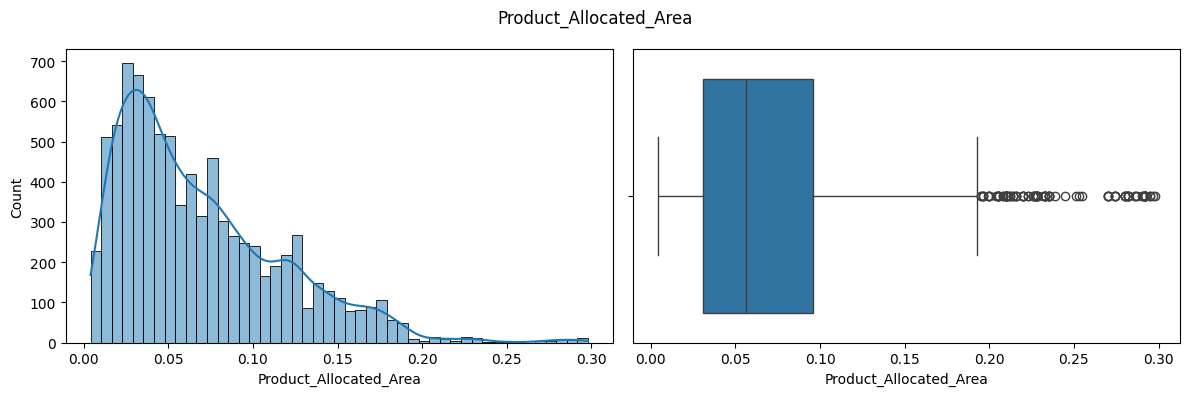

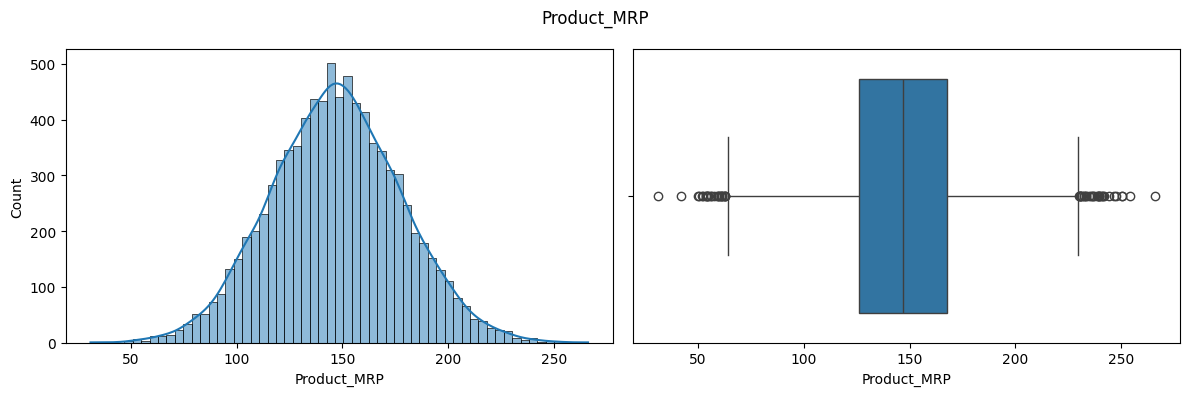

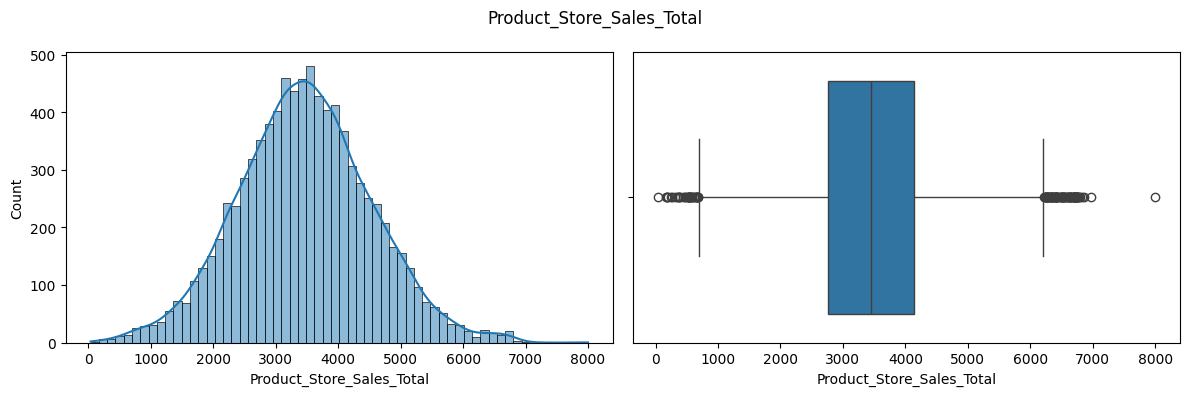

In [116]:
for col in num_cols:
  if col != "Store_Establishment_Year":
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data=superkart, x=col, kde=True, ax=axes[0])
    sns.boxplot(data=superkart, x=col, ax=axes[1])
    fig.suptitle(col)
    plt.tight_layout()
    plt.show()

# Product weight data has a normal distribution
# Product allocated area is right skewed with only higher end outliers
# Product MRP has a normal distribution around 150 dollars max retail price
# Product store sales total has a normal distribution between 3000 and 4000


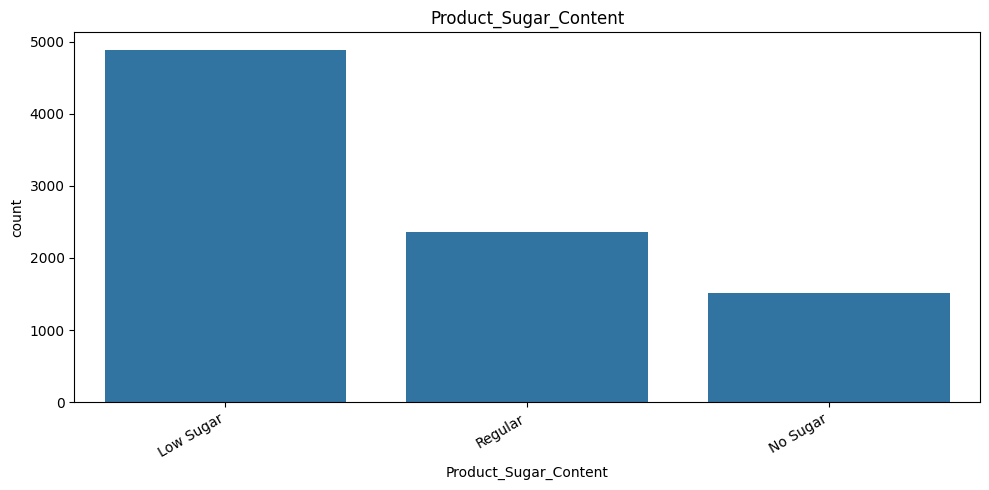

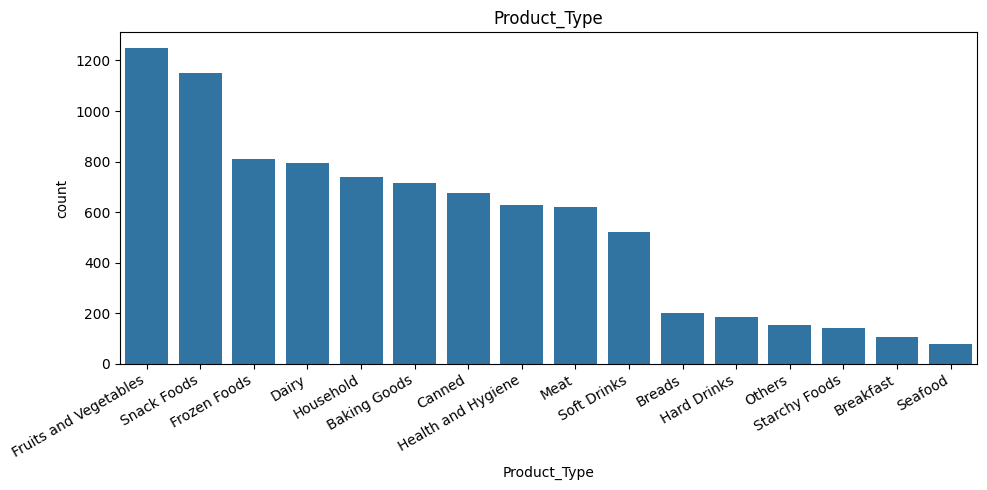

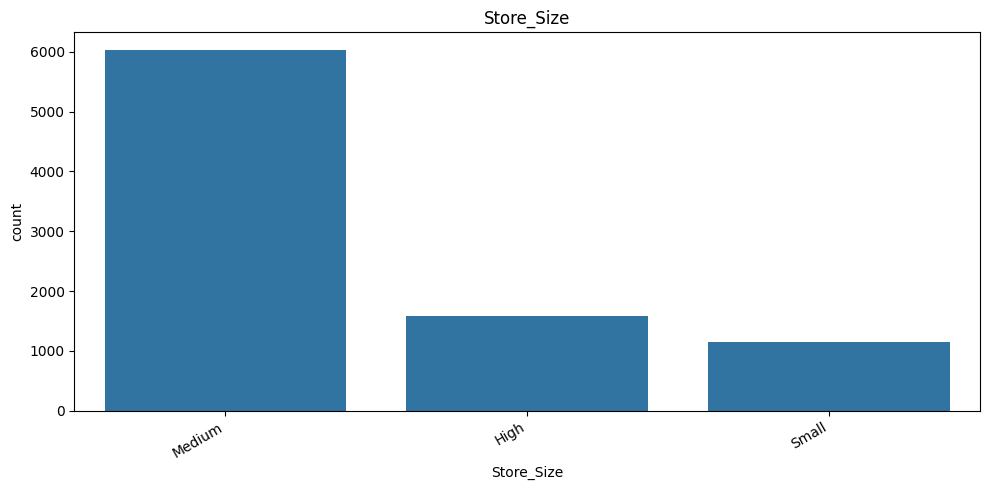

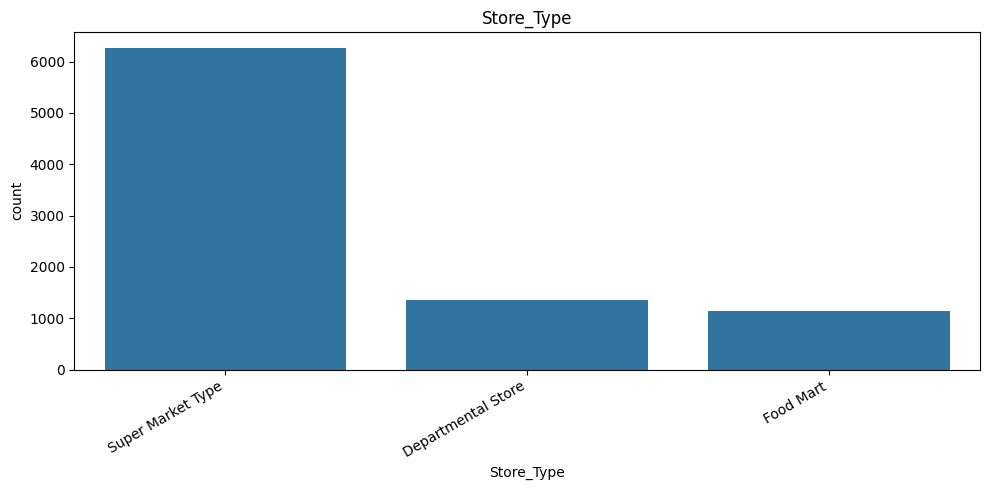

In [117]:
for col in cat_cols:
  if col != 'Store_Location_City_Type':

    plt.figure(figsize=(10, 5))
    order = superkart[col].value_counts().index
    sns.countplot(data=superkart, x=col, order=order)
    plt.xticks(rotation=30, ha="right")
    plt.title(col)
    plt.tight_layout()
    plt.show()



# A large majority of products have a low suger content.
# Stores carry alot of produce and snack foods.
# Most products are sold in a medium sized store.
# Most products are from super market.

## Bivariate Analysis

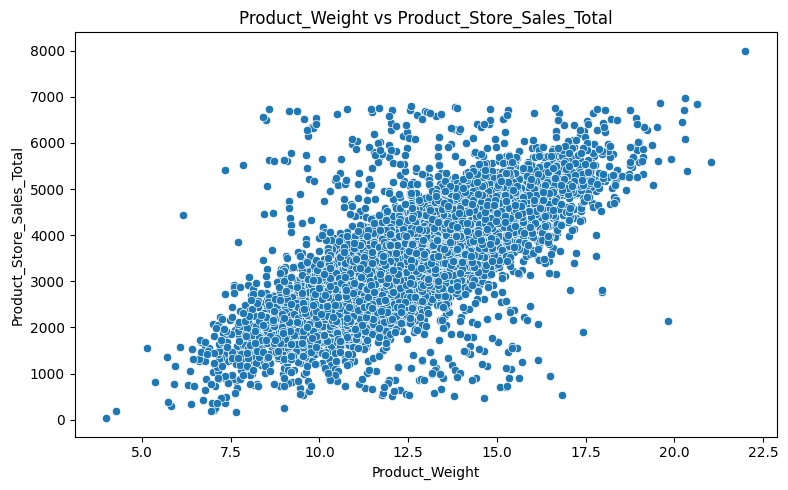

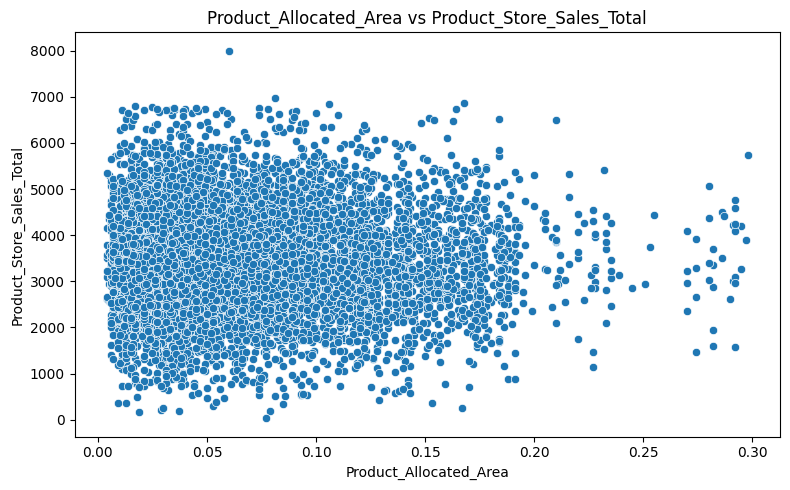

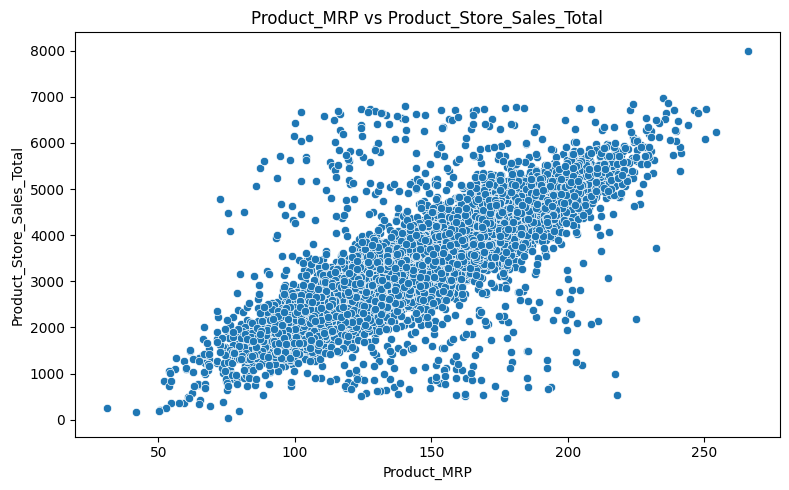

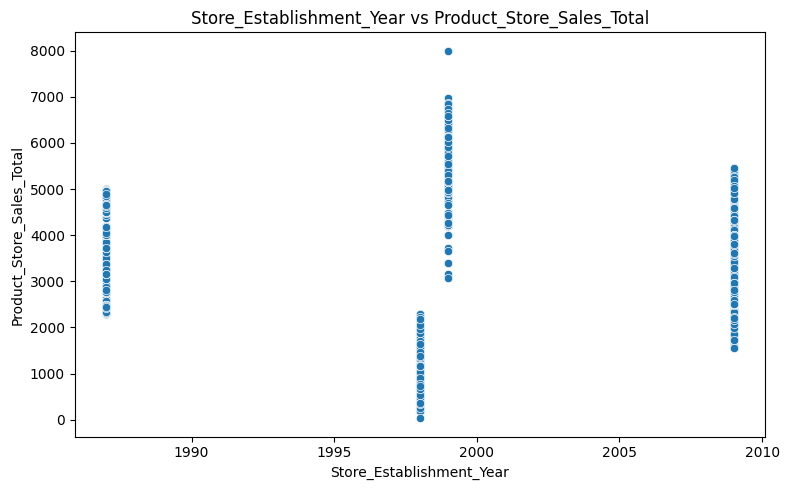

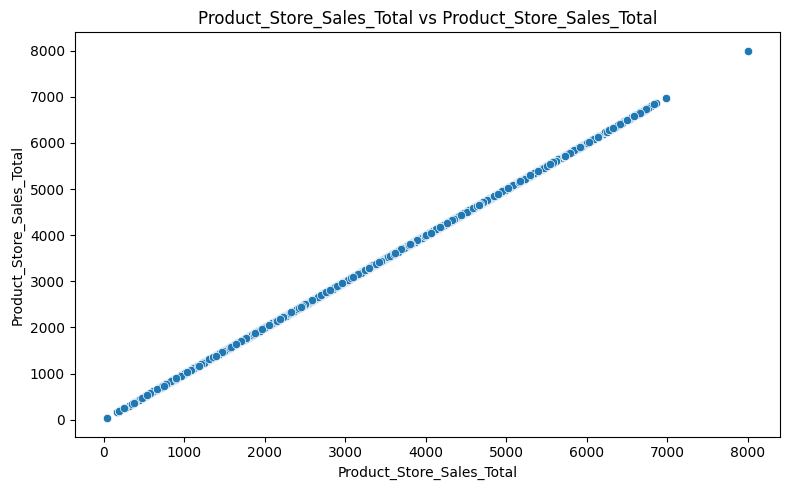

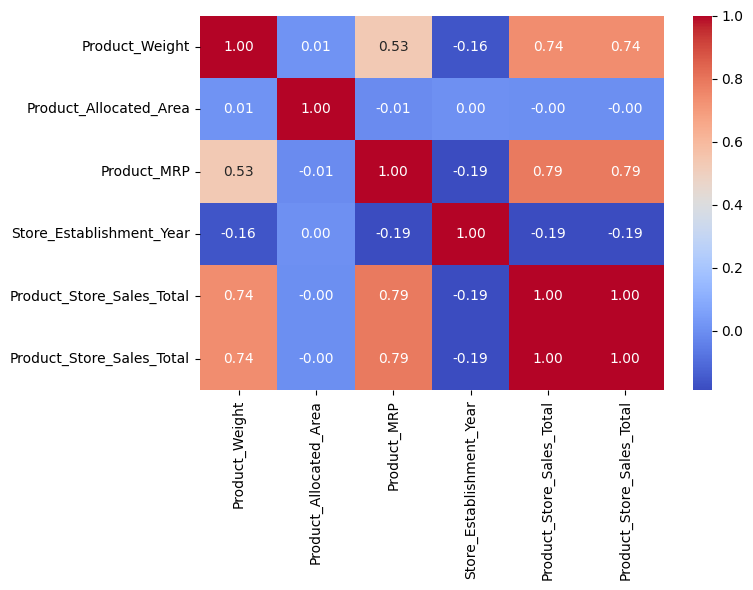

In [118]:
target = "Product_Store_Sales_Total"

for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=superkart, x=col, y=target)
    plt.title(f"{col} vs {target}")
    plt.tight_layout()
    plt.show()


plt.figure(figsize=(8, 6))
sns.heatmap(superkart[num_cols + [target]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()



# There is a positive correlation between a products weight and the total sales total of that heavier product.

# There is a positive correlation between a products max retail price and the total sales amount of the product. This makes sense, more expensive the product the more in total sales.

# Product Weight and product mrp have the highest correlation to total sales of product.

# Product MRP and Product weight also have somewhat of a correlation. Everything else not so much.

# **Data Preprocessing**

In [210]:
numeric_features = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Establishment_Year"]
categorical_features = ["Product_Sugar_Content", "Product_Type", "Store_Size", "Store_Location_City_Type", "Store_Type"]
target = "Product_Store_Sales_Total"

X = superkart[numeric_features + categorical_features]
y = superkart[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [211]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

gb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

# **Model Building**

## Define functions for Model Evaluation

In [213]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [214]:
# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

The ML models to be built can be any two out of the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

In [215]:
def evaluate(model, name):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name} - RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")
    return model

rf_model = evaluate(rf_pipeline, "Random Forest")
gb_model = evaluate(gb_pipeline, "Gradient Boosting")

Random Forest - RMSE: 283.87, MAE: 109.09, R2: 0.929
Gradient Boosting - RMSE: 310.28, MAE: 146.53, R2: 0.916


# **Model Performance Improvement - Hyperparameter Tuning**

In [216]:
rf_param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": randint(2, 11),
    "model__min_samples_leaf": randint(1, 5),
    "model__max_features": [None, 1.0, "sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
rf_model_tuned = rf_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'model__max_depth': 30, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 6, 'model__n_estimators': 379}


In [217]:

# Gradient Boosting tuning
gb_param_dist = {
    "model__n_estimators": randint(100, 400),
    "model__learning_rate": uniform(0.01, 0.2),
    "model__max_depth": randint(2, 6),
    "model__subsample": uniform(0.7, 0.3)
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    gb_param_dist,
    n_iter=20,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
gb_search.fit(X_train, y_train)
print("Best GB params:", gb_search.best_params_)
gb_model_tuned = gb_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best GB params: {'model__learning_rate': np.float64(0.019333132642723086), 'model__max_depth': 5, 'model__n_estimators': 370, 'model__subsample': np.float64(0.8368209952651107)}


# **Model Performance Comparison, Final Model Selection, and Serialization**

In [219]:
print("Random Forest - Train:")
display(model_performance_regression(rf_model, X_train, y_train))

print("Random Forest - Test:")
display(model_performance_regression(rf_model, X_test, y_test))

print("Gradient Boosting - Train:")
display(model_performance_regression(gb_model, X_train, y_train))

print("Gradient Boosting - Test:")
display(model_performance_regression(gb_model, X_test, y_test))

Random Forest - Train:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,107.018103,40.46743,0.989901,0.989888,0.015149


Random Forest - Test:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,283.874527,109.08943,0.929375,0.92901,0.038957


Gradient Boosting - Train:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,295.818735,138.125652,0.922835,0.922735,0.051419


Gradient Boosting - Test:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,310.278861,146.52732,0.915626,0.91519,0.051866


In [220]:
print("Tuned Random Forest - Train:")
display(model_performance_regression(rf_model_tuned, X_train, y_train))
print("Tuned Random Forest - Test:")
display(model_performance_regression(rf_model_tuned, X_test, y_test))

print("Tuned Gradient Boosting - Train:")
display(model_performance_regression(gb_model_tuned, X_train, y_train))
print("Tuned Gradient Boosting - Test:")
display(model_performance_regression(gb_model_tuned, X_test, y_test))

Tuned Random Forest - Train:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,183.519902,64.424395,0.970301,0.970263,0.024275


Tuned Random Forest - Test:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,277.610151,104.523732,0.932457,0.932109,0.037511


Tuned Gradient Boosting - Train:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,232.30303,96.845256,0.952414,0.952353,0.035541


Tuned Gradient Boosting - Test:


,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,282.856031,119.993679,0.929881,0.929519,0.043619


Tuned Random Forest is the best performing model on the test set, outperforming Tuned Gradient Boosting on every metric: RMSE (277.6 vs. 282.9), MAE (104.5 vs. 120.0), R2 (0.933 vs. 0.930), and MAPE (3.75% vs. 4.36%). Random Forest does show a larger relative gap between train and test error than Gradient Boosting (RMSE grows ~51% from train to test vs. GB's ~22%), suggesting slightly more overfitting, but its absolute test performance still comes out ahead. Gradient Boosting remains a reasonably close second, with the more stable train/test gap being its main advantage.

In [223]:
saved_model = rf_model_tuned

# sanity check before using it
print(saved_model.named_steps["preprocess"].feature_names_in_)

['Product_Weight' 'Product_Allocated_Area' 'Product_MRP'
 'Store_Establishment_Year' 'Product_Sugar_Content' 'Product_Type'
 'Store_Size' 'Store_Location_City_Type' 'Store_Type']


,Actual,Predicted,Residual,Abs % Error
0,3396.37,3266.766384,129.603616,3.815945
1,3371.45,3363.594078,7.855922,0.233013
2,2416.69,2415.078123,1.611877,0.066698
3,1910.53,1900.423200,10.106800,0.529005
4,3191.08,4681.009754,-1489.929754,46.690454
5,2933.24,2934.122416,-0.882416,0.030083
6,2872.85,2863.175482,9.674518,0.336757
7,3177.22,3185.454900,-8.234900,0.259186
8,3194.42,3295.935923,-101.515923,3.177914
9,539.71,1556.562505,-1016.852505,188.407201


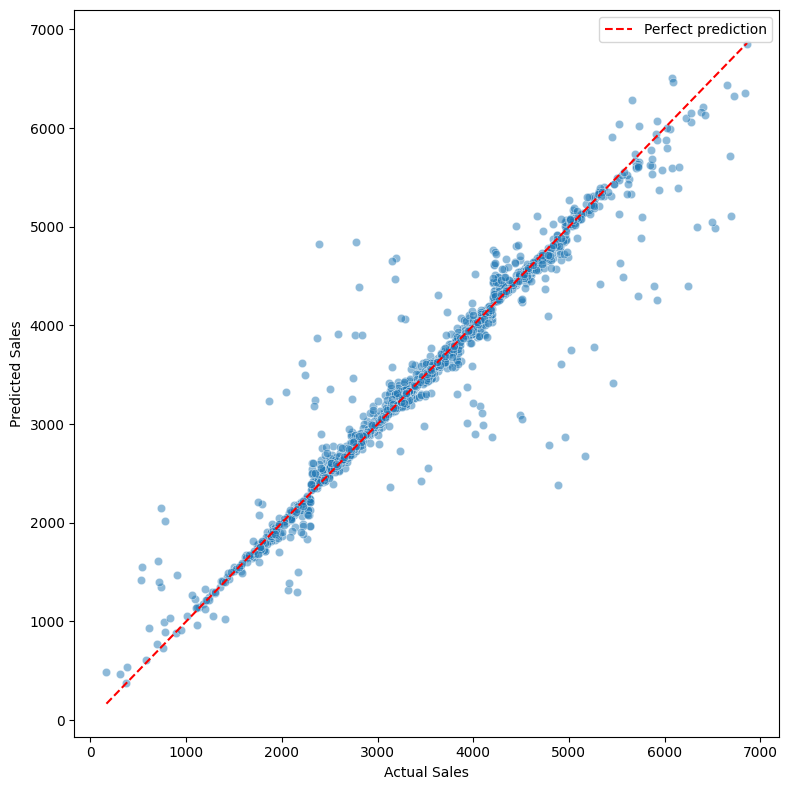

In [224]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": saved_model.predict(X_test)
})
comparison_df["Residual"] = comparison_df["Actual"] - comparison_df["Predicted"]
comparison_df["Abs % Error"] = (comparison_df["Residual"].abs() / comparison_df["Actual"]) * 100

display(comparison_df.head(20))

plt.figure(figsize=(8, 8))
sns.scatterplot(data=comparison_df, x="Actual", y="Predicted", alpha=0.5)
plt.plot([comparison_df["Actual"].min(), comparison_df["Actual"].max()],
         [comparison_df["Actual"].min(), comparison_df["Actual"].max()],
         color="red", linestyle="--", label="Perfect prediction")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.legend()
plt.tight_layout()
plt.show()

I am selecting gb_model_tuned as my final model for this app.

In [251]:
os.makedirs("deployment_files", exist_ok=True)
os.makedirs("backend_files", exist_ok=True)

model_file_name = "superkart_sales_predictor_v1"
saved_model_path = f"backend_files/{model_file_name}.joblib"
joblib.dump(rf_model_tuned, saved_model_path)
print(f"Model saved successfully at {saved_model_path}")
saved_model = joblib.load(f"backend_files/{model_file_name}.joblib")


saved_model_path = f"frontend_files/{model_file_name}.joblib"
joblib.dump(rf_model_tuned, saved_model_path)
print(f"Model saved successfully at {saved_model_path}")
saved_model = joblib.load(f"frontend_files/{model_file_name}.joblib")
print("Model loaded successfully. :D")

Model saved successfully at backend_files/superkart_sales_predictor_v1.joblib
Model saved successfully at frontend_files/superkart_sales_predictor_v1.joblib
Model loaded successfully. :D


In [252]:

model_path = f"backend_files/{model_file_name}.joblib"
saved_model = joblib.load(model_path)

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [253]:
saved_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('model',
                 RandomForestRegressor(max_depth=30, max_features=None,
                                       min_samples_leaf=2, min_samples_split=6,
                                       n_estimators=379, random_state=42))])

# **Deployment - Backend**

## Flask Web Framework


In [254]:
%%writefile backend_files/app.py
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask application
sales_predictor_api = Flask("Superkart Sales Predictor")

# Load the trained machine learning model
model = joblib.load("superkart_sales_predictor_v1.joblib")

# Define a route for the home page (GET request)
@sales_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the Superkart Sales Predictor API!"

# Define an endpoint for single product/store sales prediction (POST request)
@sales_predictor_api.post('/v1/sales')
def predict_sales():
    """
    This function handles POST requests to the '/v1/sales' endpoint.
    It expects a JSON payload containing product/store details and returns
    the predicted sales total as a JSON response.
    """
    # Get the JSON data from the request body
    product_data = request.get_json()

    # Extract relevant features from the JSON data
    sample = {
        'Product_Weight': product_data['Product_Weight'],
        'Product_Allocated_Area': product_data['Product_Allocated_Area'],
        'Product_MRP': product_data['Product_MRP'],
        'Store_Establishment_Year': product_data['Store_Establishment_Year'],
        'Product_Sugar_Content': product_data['Product_Sugar_Content'],
        'Product_Type': product_data['Product_Type'],
        'Store_Size': product_data['Store_Size'],
        'Store_Location_City_Type': product_data['Store_Location_City_Type'],
        'Store_Type': product_data['Store_Type']
    }

    # Convert the extracted data into a Pandas DataFrame
    input_data = pd.DataFrame([sample])

    # Make prediction
    predicted_sales = model.predict(input_data)[0]

    # Convert predicted_sales to Python float
    # (needed because NumPy float32/64 values raise a datatype error in jsonify)
    predicted_sales = round(float(predicted_sales), 2)

    # Return the predicted sales total
    return jsonify({'Predicted Sales Total (in dollars)': predicted_sales})


# Define an endpoint for batch prediction (POST request)
@sales_predictor_api.post('/v1/salesbatch')
def predict_sales_batch():
    """
    This function handles POST requests to the '/v1/salesbatch' endpoint.
    It expects a CSV file containing product/store details for multiple
    products and returns the predicted sales totals as a dictionary in
    the JSON response.
    """
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the CSV file into a Pandas DataFrame
    input_data = pd.read_csv(file)

    # Make predictions for all rows in the DataFrame
    predicted_sales = model.predict(input_data).tolist()
    predicted_sales = [round(float(sales), 2) for sales in predicted_sales]

    # Create a dictionary of predictions with Product_Id as keys
    product_ids = input_data['Product_Id'].tolist()
    output_dict = dict(zip(product_ids, predicted_sales))

    # Return the predictions dictionary as a JSON response
    return jsonify(output_dict)

# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    sales_predictor_api.run(debug=True)

Overwriting backend_files/app.py


## Dependencies File

In [230]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

Overwriting backend_files/requirements.txt


## Dockerfile

In [231]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:sales_predictor_api"]

Overwriting backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [255]:
from huggingface_hub import create_repo
create_repo(repo_id="samdandy/superkart-backend", repo_type="space", space_sdk="docker", exist_ok=True)
create_repo(repo_id="samdandy/superkart-frontend", repo_type="space", space_sdk="docker", exist_ok=True)

RepoUrl('https://huggingface.co/spaces/samdandy/superkart-frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='samdandy/superkart-frontend')

In [256]:
from huggingface_hub import login, upload_folder
upload_folder(folder_path="backend_files", repo_id="samdandy/superkart-backend", repo_type="space")

Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...superkart_sales_predictor_v1.joblib:   3%|2         | 2.14MB / 73.0MB            

CommitInfo(commit_url='https://huggingface.co/spaces/samdandy/superkart-backend/commit/4c8809ff5cd06710d66be0f377efe31570190879', commit_message='Upload folder using huggingface_hub', commit_description='', oid='4c8809ff5cd06710d66be0f377efe31570190879', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/samdandy/superkart-backend', endpoint='https://huggingface.co', repo_type='space', repo_id='samdandy/superkart-backend'), pr_revision=None, pr_num=None)

In [164]:
os.makedirs("frontend_files", exist_ok=True)

# **Deployment - Frontend**

## Uploading Files to Hugging Face Space (Docker Space)

## Points to note before executing the below cells
- Create a Streamlit space on Hugging Face by following the instructions provided on the content page titled **`Creating Spaces and Adding Secrets in Hugging Face`** from Week 1

In [298]:
%%writefile frontend_files/app.py
import streamlit as st
import requests

st.title("Superkart Sales Prediction")

BACKEND_URL = "https://samdandy-superkart-backend.hf.space"

# Section for online prediction
st.subheader("Online Prediction")

product_weight = st.number_input("Product Weight", min_value=0.0, value=9.8, step=0.1)
product_allocated_area = st.number_input("Product Allocated Area", min_value=0.0, value=0.062, step=0.001, format="%.3f")
product_mrp = st.number_input("Product MRP", min_value=0.0, value=205.5, step=1.0)
store_establishment_year = st.number_input("Store Establishment Year", min_value=1900, max_value=2026, value=2015, step=1)

product_sugar_content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
product_type = st.selectbox("Product Type", ["Dairy", "Soft Drinks", "Meat", "Fruits and Vegetables",
                                              "Household", "Baking Goods", "Snack Foods", "Frozen Foods",
                                              "Breakfast", "Health and Hygiene", "Hard Drinks", "Canned",
                                              "Breads", "Starchy Foods", "Others", "Seafood"])
store_size = st.selectbox("Store Size", ["Small", "Medium", "High"])
store_location_city_type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"])
store_type = st.selectbox("Store Type", ["Supermarket Type", "Departmental Store", "Food Mart"])

if st.button("Predict"):
    payload = {
        "Product_Weight": float(product_weight),
        "Product_Allocated_Area": float(product_allocated_area),
        "Product_MRP": float(product_mrp),
        "Store_Establishment_Year": int(store_establishment_year),
        "Product_Sugar_Content": product_sugar_content,
        "Product_Type": product_type,
        "Store_Size": store_size,
        "Store_Location_City_Type": store_location_city_type,
        "Store_Type": store_type
    }
    print(payload)
    try:
        url = f"{BACKEND_URL}/v1/sales"
        print(url)
        response = requests.post(f"{BACKEND_URL}/v1/sales", json=payload, timeout=15)
        if response.status_code == 200:
            prediction = response.json()["Predicted Sales Total (in dollars)"]
            st.success(f"Predicted Sales Total (in dollars): {prediction}")
        else:
            st.error(f"Error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Request failed: {e}, {payload}")

# Section for batch prediction
st.subheader("Batch Prediction")

uploaded_file = st.file_uploader("Upload CSV file for batch prediction", type=["csv"])

if uploaded_file is not None and st.button("Predict Batch"):
    try:
        files = {"file": (uploaded_file.name, uploaded_file.getvalue(), "text/csv")}
        response = requests.post(f"{BACKEND_URL}/v1/salesbatch", files=files, timeout=30)
        if response.status_code == 200:
            st.success("Batch predictions completed!")
            st.write(response.json())
        else:
            st.error(f"Error {response.status_code}: {response.text}")
    except requests.exceptions.RequestException as e:
        st.error(f"Request failed: {e}")

Overwriting frontend_files/app.py


In [248]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


In [268]:
%%writefile frontend_files/README.md
---
title: Superkart Sales Predictor
colorFrom: blue
colorTo: green
sdk: docker
app_port: 8501
---

Overwriting frontend_files/README.md


In [293]:
%%writefile frontend_files/Dockerfile
FROM python:3.9-slim

WORKDIR /app

COPY . .

RUN pip3 install -r requirements.txt
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Overwriting frontend_files/Dockerfile


In [299]:
from huggingface_hub import login, upload_folder
upload_folder(folder_path="frontend_files", repo_id="samdandy/superkart-frontend", repo_type="space")


Processing Files (0 / 0)                : |          |  0.00B /  0.00B            

New Data Upload                         : |          |  0.00B /  0.00B            

  ...superkart_sales_predictor_v1.joblib:  55%|#####4    | 40.0MB / 73.0MB            

CommitInfo(commit_url='https://huggingface.co/spaces/samdandy/superkart-frontend/commit/e78fd48da9a7bcd137b7229f3036a3c1cda608a8', commit_message='Upload folder using huggingface_hub', commit_description='', oid='e78fd48da9a7bcd137b7229f3036a3c1cda608a8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/samdandy/superkart-frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='samdandy/superkart-frontend'), pr_revision=None, pr_num=None)

In [285]:
import requests
sample_payload = {
    'Product_Weight': 9.8,
    'Product_Allocated_Area': 0.062,
    'Product_MRP': 205.50,
    'Store_Establishment_Year': 2015,
    'Product_Sugar_Content': 'Regular',
    'Product_Type': 'Snack Foods',
    'Store_Size': 'Small',
    'Store_Location_City_Type': 'Tier 3',
    'Store_Type': 'Food Mart'
}
response = requests.post("https://samdandy-superkart-backend.hf.space/v1/sales", json=sample_payload)
print(response.text)

{"Predicted Sales Total (in dollars)":2479.5}



# **Actionable Insights and Business Recommendations**

I would advise to use the tuned random forest model for sales predictions. It beats the tuned gradient boosting model on every test metric (RMSE 277.6 vs 282.9, MAPE 3.75% vs 4.36%), so it'll give the tightest range of income they can expect. Worth keeping an eye on though — its train-test gap is a bit wider than gradient boosting's, so it may need retraining periodically as new sales data comes in.

In [282]:
!jupyter nbconvert --to html /content/Full_Code_SuperKart_Model.ipynb

[NbConvertApp] Converting notebook /content/Full_Code_SuperKart_Model.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 15 image(s).
[NbConvertApp] Writing 1645326 bytes to /content/Full_Code_SuperKart_Model.html
